# **Image Captioning**

<div style="border: 3px solid #222; padding: 16px; border-radius: 10px; background-color: #1c1f26; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; color: #e0e0e0;">
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #ff5555;">&#128274;</span>
    <span style="font-size: 16px;"><strong>Project:</strong> ELTE Homework Project</span>
  </div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #ff5555;">&#128218;</span>
    <span style="font-size: 16px;"><strong>Course:</strong> Deep Network Development 25/26/2</span>
  </div>
  <div style="display: flex; align-items: center; gap: 8px; margin-top: 12px;">
    <span style="font-size: 24px; color: #6e8192;">&#128100;</span>
    <span style="font-size: 16px;"><strong>Authors:</strong> Mashile Clerence (MSc student, Department of Data Science, Eötvös Loránd University) </span>
  </div>
</div>
<hr style="border: none; border-top: 2px solid #444;">
<br>

<img src="https://repository-images.githubusercontent.com/83958320/8f162500-8ace-11e9-94ee-0b86d27bbc5e" alt="1" border="0">

This notebook contains the required task for the **seccond homework** of the **Deep Network Development (DNDEG)** course.

---

## **Task Description**

Train your **own custom image captioning model** and compare its performance with an existing **pre-trained** model using the `MS COCO Captions 2017` dataset.

### Architecture

Your model must follow an **Encoder-Attention-Transformer Decoder** architecture:
- **Encoder:** Pre-trained CNN backbone (e.g., ResNet) that must be **fine-tuned** during training.
- **Decoder:** Transformer-based with multi-head self-attention and cross-attention layers.
- **Controllable Generation:** At least one control mechanism (caption length, style, or focus).
- **Cross-Attention Visualization:** Visualize which image regions the decoder attends to for each generated word.

### Dataset

The **MS COCO Captions 2017** dataset:
- **Training set:** ~118K images with 5 captions each
- **Validation set:** ~5K images with 5 captions each

**Download links:**
- Images (Train): http://images.cocodataset.org/zips/train2017.zip (~18GB)
- Images (Val): http://images.cocodataset.org/zips/val2017.zip (~1GB)
- Annotations: http://images.cocodataset.org/annotations/annotations_trainval2017.zip (~241MB)

Consider limiting the vocabulary to words appearing at least 5 times.

> ⚠️ **Hardware Note:** May reduce the dataset size (e.g., use a subset of the training images) to fit your current hardware capabilities or cloud resource availability. Ensure you document any such modifications in your notebook.

---

## **Requirements**

**Data Preparation:**
- Download and prepare the MS COCO Captions 2017 dataset
- Display sample images with their original and tokenized captions

**Model Training:**
- Train an Encoder-Attention-Transformer Decoder model
- Track training and validation loss with visualizations
- Monitor BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores
- Implement overfitting prevention (early stopping, regularization, learning rate scheduling)
- Save the best-performing model checkpoint

**Evaluation:**
- Compute BLEU scores using all 5 reference captions per image
- Visualize cross-attention weights showing what the model attends to
- Compare your model with a pre-trained model (e.g., BLIP, ViT-GPT2) on the same validation images
- Provide written analysis of the strengths and weaknesses of both models

> ⚠️ **Performance Note:** Model is not expected to achieve state-of-the-art results, but it should perform better than random guessing and show decreasing loss during training.

## **Notebook Structure**

The following sections will guide you through the task:

0. Necessary imports
1. Data loading process
2. Defining data augmentations
3. Creating datasets and dataloaders
4. Visualizing training data
5. Creating the image captioning model
6. Defining loss function and optimizer
7. Training the model
8. Evaluation (metrics, cross-attention visualization, inference)
9. Loading a pre-trained model
10. Evaluating the pre-trained model
11. Comparing the two models

The sections are there for guidance and **need not need be followed strictly**. Feel free to add more code cells as needed, but keep all code within this notebook (no external `.py` files).


## **0. Necessary Imports**
Importing all the necessary packages for this assignment. **ONLY PYTORCH MODELS ARE USED!**

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import nltk
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import math
import random
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from collections import Counter

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# For COCO dataset loading
# !pip install pycocotools
# from pycocotools.coco import COCO

Using device: cuda:0


## **1. Data Loading Process**

For this assignment you will be using the [MS COCO Captions 2017](https://cocodataset.org/#captions-2017) dataset, which contains **captions/descriptions** of diverse images.

<img src="https://cocodataset.org/images/coco-examples.jpg" alt="COCO Examples" border="0" width="600">

**Download Commands:**

```bash
# Download images
wget http://images.cocodataset.org/zips/train2017.zip        # ~18GB, 118K images
wget http://images.cocodataset.org/zips/val2017.zip          # ~1GB, 5K images

# Download annotations (includes captions)
wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip  # ~241MB
```

After downloading, extract and organize the data:

```
coco/
├── images/
│   ├── train2017/
│   └── val2017/
└── annotations/
    ├── captions_train2017.json
    └── captions_val2017.json
```

You can use the official `pycocotools` library to load and parse the annotations:

```python
!pip install pycocotools
from pycocotools.coco import COCO

coco = COCO('annotations/captions_train2017.json')
```

In [ ]:
# ADD YOUR CODE HERE
import zipfile

DATA_DIR = 'coco'
IMAGE_DIR_TRAIN = os.path.join(DATA_DIR, 'images', 'train2017')
IMAGE_DIR_VAL = os.path.join(DATA_DIR, 'images', 'val2017')
ANNOTATION_DIR = os.path.join(DATA_DIR, 'annotations')

URLS = { 'train_images': 'http://images.cocodataset.org/zips/train2017.zip', 'val_images': 'http://images.cocodataset.org/zips/val2017.zip',
    'annotations': 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip' }

os.makedirs(IMAGE_DIR_TRAIN, exist_ok=True)
os.makedirs(IMAGE_DIR_VAL, exist_ok=True)
os.makedirs(ANNOTATION_DIR, exist_ok=True)

print("Downloading and extracting COCO dataset...")

for name, url in URLS.items():
    zip_filename = os.path.join(DATA_DIR, os.path.basename(url))
    print(f"Downloading {name} from {url} to {zip_filename}...")

    !wget -nc -P {DATA_DIR} {url}

    print(f"Extracting {zip_filename}...")
    if name == 'train_images':
        !unzip -q {zip_filename} -d {os.path.join(DATA_DIR, 'images')}
    elif name == 'val_images':
        !unzip -q {zip_filename} -d {os.path.join(DATA_DIR, 'images')}
    elif name == 'annotations':
        !unzip -q {zip_filename} -d {ANNOTATION_DIR}

    print(f"Removing {zip_filename}...")
    os.remove(zip_filename)

print("COCO dataset download and extraction complete!")

print("\nVerifying directory structure:")
print(f"Images Train: {len(os.listdir(IMAGE_DIR_TRAIN))} files")
print(f"Images Val: {len(os.listdir(IMAGE_DIR_VAL))} files")
print(f"Annotations: {os.listdir(ANNOTATION_DIR)}")

--2026-05-18 19:05:06--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.254.22, 54.231.168.65, 52.217.46.68, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.254.22|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘coco/train2017.zip’

train2017.zip       100%[===================>]  18.01G  34.5MB/s    in 12m 15s 

2026-05-18 19:17:21 (25.1 MB/s) - ‘coco/train2017.zip’ saved [19336861798/19336861798]

Extracting coco/train2017.zip...
replace coco/images/train2017/000000147328.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace coco/images/train2017/000000414738.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
replace coco/images/train2017/000000281563.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
replace coco/images/train2017/000000063879.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
replace coco/images/train2017/00000053134

## **2. Defining Augmentations**

When applying **augmentations** to the `COCO Captions` dataset, it is important to note that these transformations should be applied **only to the images** and not to the captions.

Ensure that your **data augmentation pipeline** includes:
- A **normalization step** to scale pixel values appropriately.
- A **tensor conversion step** to transform images into tensors for model compatibility.
- Additional **augmentations of your choice**, such as random cropping, flipping, or color jittering, to enhance model generalization.

```python
train_transforms = transforms.Compose([
            # Add Augmentations
])

test_transforms = transforms.Compose([
            # Add Augmentations
])
```

In [ ]:
# ADD YOUR CODE HERE
train_transforms = transforms.Compose([transforms.RandomResizedCrop(256),
    transforms.RandomHorizontalFlip(), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) ])

test_transforms = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(256), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) ])

## **3. Creating Datasets and Dataloaders**

To load the **COCO Captions** dataset, you need to create a **custom PyTorch** `Dataset` class that returns **images and their corresponding captions**. The captions should be **tokenized** before being returned.

Make sure to include special tokens in your tokenized captions:
- `<sos>` or `<bos>` (Start of Sentence)
- `<eos>` (End of Sentence)
- `<unk>` (Unknown Token) for words outside the vocabulary
- `<pad>` (Padding Token) for batch processing

It is recommended to build a **Vocabulary class** to store all the words in your dataset, as your model can only generate words that exist in this vocabulary. However, saving every word is unnecessary. A **common practice** is to include only words that appear **at least 5 times** across the entire dataset to reduce noise and improve model efficiency.

For the **DataLoader**, ensure that the **batch size** is appropriate so that it fits into memory. Set the **`shuffle`** parameter as follows:

- **Training DataLoader:** `shuffle=True` (to randomize the order of samples)  
- **Validation DataLoader:** `shuffle=False` (to maintain consistency in evaluation)

> **Note**: Remember that batches contain examples with **different caption lengths**. Use a custom `collate_fn` to handle padding and create attention masks for the Transformer decoder.

```python
class Vocabulary:
    """Vocabulary class to map words to indices."""
    def __init__(self, freq_threshold=5):
        raise NotImplementedError

    def build_vocabulary(self, captions):
        raise NotImplementedError

    def numericalize(self, text):
        # Returns: list of token indices
        raise NotImplementedError


class COCOCaptionsDataset(Dataset):
    def __init__(self, root, annFile, vocab, transform=None):
        raise NotImplementedError

    def __len__(self):
        raise NotImplementedError

    def __getitem__(self, idx):
        # Returns: image, caption_tokens, caption_length
        raise NotImplementedError


def collate_fn(batch):
    # Returns: images, padded_captions, lengths, attention_masks
    raise NotImplementedError
```

In [ ]:
import random
from pycocotools.coco import COCO

class Vocabulary:
    """Vocabulary class to map words to indices."""
    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.next_idx = 4

    def __len__(self):
        return len(self.itos)

    def build_vocabulary(self, annotations):
        """Builds the vocabulary from a list of COCO annotation objects."""
        word_counts = Counter()
        for ann in annotations:
            caption = ann['caption']
            tokens = nltk.tokenize.word_tokenize(caption.lower())
            word_counts.update(tokens)

        for word, count in word_counts.items():
            if count >= self.freq_threshold:
                if word not in self.stoi:
                    self.stoi[word] = self.next_idx
                    self.itos[self.next_idx] = word
                    self.next_idx += 1

    def numericalize(self, text):
        """Converts a text caption into a list of numerical indices."""
        tokens = nltk.tokenize.word_tokenize(text.lower())
        numericalized_caption = [self.stoi["<sos>"]]
        for token in tokens:
            numericalized_caption.append(self.stoi.get(token, self.stoi["<unk>"]))
        numericalized_caption.append(self.stoi["<eos>"])
        return numericalized_caption

class COCOCaptionsDataset(Dataset):
    def __init__(self, root, annFile, vocab, transform=None, subset_size=None):
        self.root = root
        self.coco = COCO(annFile)
        self.vocab = vocab
        self.transform = transform

        self.annotations = []
        all_image_ids_in_annfile = self.coco.getImgIds()
        existing_filenames_in_root = set(os.listdir(self.root))

        temp_annotations = []
        for img_id in all_image_ids_in_annfile:
            img_info = self.coco.loadImgs(img_id)[0]
            img_filename = img_info['file_name']

            if img_filename in existing_filenames_in_root:
                ann_ids_for_this_img = self.coco.getAnnIds(imgIds=img_id)

                for ann_id in ann_ids_for_this_img:
                    temp_annotations.append(self.coco.anns[ann_id])

        if subset_size is not None and subset_size < len(temp_annotations):
            self.annotations = random.sample(temp_annotations, subset_size)
        else:
            self.annotations = temp_annotations


    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        original_idx = idx
        retries = 0
        max_retries = len(self.annotations)

        while retries < max_retries:
            try:
                ann_info = self.annotations[idx]
                caption = ann_info['caption']
                img_id = ann_info['image_id']

                img_info = self.coco.loadImgs(img_id)[0]
                img_path = os.path.join(self.root, img_info['file_name'])

                image = Image.open(img_path).convert("RGB")
                if self.transform:
                    image = self.transform(image)

                caption_tokens = self.vocab.numericalize(caption)
                caption_tokens = torch.tensor(caption_tokens, dtype=torch.long)

                return image, caption_tokens, img_id

            except (IOError, FileNotFoundError, Image.UnidentifiedImageError, OSError) as e:
                retries += 1
                idx = (original_idx + retries) % len(self.annotations)
                if idx == original_idx:
                    break
            except Exception as e:
                print(f"ERROR: Unexpected error in __getitem__ for idx {idx}, path {img_path}: {e}")
                raise

        raise RuntimeError(f"Failed to load a valid image after {retries} attempts starting from idx {original_idx}.")

def collate_fn(batch):
    """Collate function to pad captions to the maximum length in a batch."""

    batch.sort(key=lambda x: len(x[1]), reverse=True)
    images, captions, img_ids = zip(*batch)
    images = torch.stack(images, 0)
    img_ids = torch.tensor(list(img_ids), dtype=torch.long)

    lengths = torch.tensor([len(cap) for cap in captions])
    target_captions = torch.zeros(len(captions), max(lengths)).long()
    for i, cap in enumerate(captions):
        end = lengths[i]
        target_captions[i, :end] = cap[:end]

    attention_masks = (target_captions == 0)

    return images, target_captions, lengths, attention_masks, img_ids

## **4. Visualizing Training Data**

To visualize the training data, extract a batch from the training `DataLoader` and plot the **input-target** pairs using `Matplotlib` or `Seaborn`. Ensure that at least **8 pairs** are displayed for a clear representation.

Make sure to **visualize the original and the tokenized caption** as well!

```python
def visualize_batch(dataloader, vocab, num_samples=8):
    raise NotImplementedError
```

In [ ]:
def visualize_batch(dataloader, vocab, num_samples=8):
    """Visualizes a batch of images and their captions."""
    dataiter = iter(dataloader)
    images, captions, lengths, _, _ = next(dataiter)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    plt.figure(figsize=(15, num_samples * 2))
    for i in range(min(num_samples, len(images))):
        plt.subplot(num_samples, 1, i + 1)

        img = images[i].cpu()
        img = img * std + mean
        img = np.transpose(img.numpy(), (1, 2, 0)) # C, H, W to H, W, C
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.axis('off')

        tokenized_caption_indices = captions[i][:lengths[i]].tolist()
        original_caption_words = [vocab.itos[idx] for idx in tokenized_caption_indices]
        original_caption_str = ' '.join(original_caption_words)

        plt.title(f"Original (Reconstructed): {original_caption_str}\nTokenized: {tokenized_caption_indices}")

    plt.tight_layout()
    plt.show()

In [ ]:
from pycocotools.coco import COCO

TRAIN_ANN_FILE = os.path.join(ANNOTATION_DIR, 'annotations', 'captions_train2017.json')
VAL_ANN_FILE = os.path.join(ANNOTATION_DIR, 'annotations', 'captions_val2017.json')

vocab = Vocabulary(freq_threshold=5)

train_coco = COCO(TRAIN_ANN_FILE)
train_annotations = [train_coco.anns[ann_id] for ann_id in train_coco.anns]
vocab.build_vocabulary(train_annotations)

TRAIN_SUBSET_SIZE = 10000
VAL_SUBSET_SIZE = 2000

train_dataset = COCOCaptionsDataset(root=IMAGE_DIR_TRAIN, annFile=TRAIN_ANN_FILE, vocab=vocab, transform=train_transforms, subset_size=TRAIN_SUBSET_SIZE)
val_dataset = COCOCaptionsDataset(root=IMAGE_DIR_VAL, annFile=VAL_ANN_FILE, vocab=vocab, transform=test_transforms, subset_size=VAL_SUBSET_SIZE)

print(f"Train dataset size (subset): {len(train_dataset)}")
print(f"Validation dataset size (subset): {len(val_dataset)}")

NUM_DATALOADER_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=NUM_DATALOADER_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=NUM_DATALOADER_WORKERS, collate_fn=collate_fn)


loading annotations into memory...
Done (t=0.96s)
creating index...
index created!
loading annotations into memory...
Done (t=0.94s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Train dataset size (subset): 10000
Validation dataset size (subset): 2000


Visualizing a batch of training data...


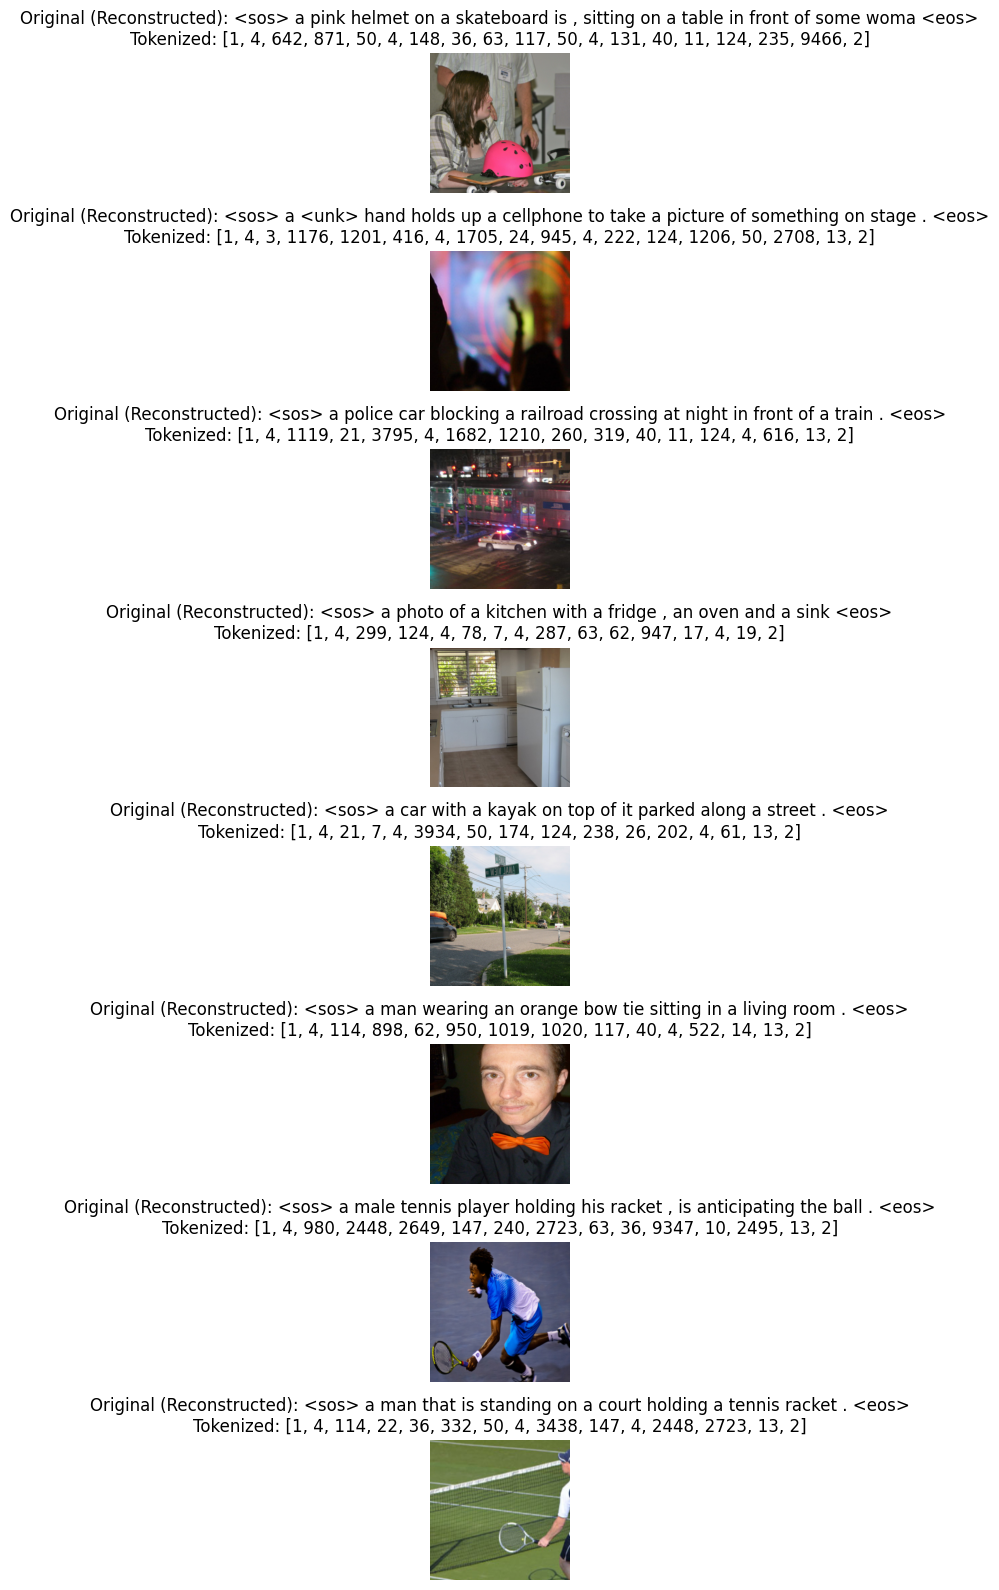

In [ ]:
print("Visualizing a batch of training data...")
visualize_batch(train_loader, vocab, num_samples=8)

## **5. Creating the Image Captioning Model**

For this assignment, **you are required to create your own custom image captioning model** and **compare its performance** with an existing pre-trained model.

---

### **Encoder-Attention-Transformer Decoder Architecture**

Your model must follow an **Encoder-Attention-Transformer Decoder** architecture:

#### **1. Encoder (CNN-based)**
The encoder processes images to extract spatial features:
- Use a **pre-trained CNN** (e.g., ResNet-50, ResNet-101) as the backbone.
- Remove the final classification layers to obtain feature maps.
- **Fine-tuning is required** - at minimum, fine-tune the last few layers.
- Output shape should be `(batch_size, num_patches, encoder_dim)` where patches come from spatial locations in the feature map.

#### **2. Transformer Decoder**
The decoder must be **Transformer-based** with the following components:
- **Positional Encoding** for caption token positions.
- **Masked Multi-Head Self-Attention** to prevent attending to future tokens.
- **Cross-Attention** layers to attend to encoder features (image patches).
- **Feed-Forward Networks** with residual connections and layer normalization.

> **Note:** An LSTM/GRU decoder is **not acceptable** for this assignment. You must implement a Transformer decoder.

#### **3. Controllable Generation**
Implement at least one form of caption control:
- **Length Control:** Condition the decoder on desired caption length (short/medium/long).
- **Style Control:** Add style embeddings (formal/casual/descriptive).
- **Focus Control:** Emphasize specific detected objects or regions.

This can be done by adding **control embeddings** to the decoder input or using **special control tokens**.

---

### **Code Skeleton**

```python
class CNNEncoder(nn.Module):
    """CNN-based image encoder using pre-trained backbone."""
    def __init__(self, encoder_dim=2048, fine_tune_from=6):
        super(CNNEncoder, self).__init__()
        # Load pre-trained ResNet, remove final layers
        # Enable fine-tuning for layers >= fine_tune_from
        raise NotImplementedError

    def forward(self, images):
        # Returns: (batch_size, num_patches, encoder_dim)
        raise NotImplementedError
```

```python
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer."""
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        raise NotImplementedError

    def forward(self, x):
        raise NotImplementedError
```

```python
class TransformerDecoderLayer(nn.Module):
    """Single Transformer decoder layer with masked self-attention and cross-attention."""
    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.1):
        super(TransformerDecoderLayer, self).__init__()
        # Masked multi-head self-attention
        # Cross-attention to encoder features
        # Feed-forward network
        raise NotImplementedError

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # Returns: output, cross_attention_weights (for visualization)
        raise NotImplementedError
```

```python
class TransformerDecoder(nn.Module):
    """Full Transformer decoder with embedding and output projection."""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, dim_feedforward, dropout=0.1):
        super(TransformerDecoder, self).__init__()
        # Word embedding + positional encoding
        # Control embedding (for controllable generation)
        # Stack of TransformerDecoderLayer
        # Output projection to vocab
        raise NotImplementedError

    def forward(self, captions, encoder_features, tgt_mask=None, control_signal=None):
        # control_signal: optional (e.g., desired length, style)
        # Returns: logits, list of cross_attention_weights from each layer
        raise NotImplementedError

    def generate_square_subsequent_mask(self, sz):
        """Generate causal mask for autoregressive decoding."""
        raise NotImplementedError
```

```python
class ImageCaptioningModel(nn.Module):
    """Full image captioning model: Encoder + Transformer Decoder."""
    def __init__(self, vocab_size, encoder_dim, d_model, num_heads, num_layers, dim_feedforward):
        super(ImageCaptioningModel, self).__init__()
        raise NotImplementedError

    def forward(self, images, captions, control_signal=None):
        # Returns: logits, cross_attention_weights
        raise NotImplementedError

    def generate(self, images, max_len=50, control_signal=None):
        """Autoregressive caption generation (greedy or beam search)."""
        raise NotImplementedError
```

In [ ]:
class CNNEncoder(nn.Module):
    """CNN-based image encoder using pre-trained backbone."""
    def __init__(self, encoder_dim=2048, fine_tune_from=6):
        super(CNNEncoder, self).__init__()
        # Load pre-trained ResNet-101
        resnet = torchvision.models.resnet101(weights=torchvision.models.ResNet101_Weights.DEFAULT)

        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        self.linear = nn.Linear(2048, encoder_dim)
        self.bn = nn.BatchNorm1d(encoder_dim, momentum=0.01)

        for param in self.resnet.parameters():
            param.requires_grad = False

        for i, child in enumerate(self.resnet.children()):
            if i >= fine_tune_from:
                for param in child.parameters():
                    param.requires_grad = True

    def forward(self, images):
        """Forward pass to extract regional features."""
        # Input: (batch_size, 3, 256, 256) -> Output: (batch_size, 2048, 8, 8)
        features = self.resnet(images)
        features = features.permute(0, 2, 3, 1)
        features = features.reshape(features.size(0), -1, features.size(3))

        batch_size, seq_len, channels = features.size()
        features = features.reshape(-1, channels)
        features = self.bn(self.linear(features))
        features = features.reshape(batch_size, seq_len, -1) # (batch_size, 64, encoder_dim)

        return features

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding compatible with batch_first=True."""
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # Shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """Adds positional encoding to (batch_size, seq_len, d_model)."""
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerDecoderLayer(nn.Module):
    """Single Transformer decoder layer with masked self-attention and cross-attention."""
    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.3):
        super(TransformerDecoderLayer, self).__init__()

        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.multihead_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)

        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

        self.activation = nn.ReLU()

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # Self-attention over text tokens
        tgt2, self_attn_weights = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask, key_padding_mask=tgt_key_padding_mask)
        tgt = tgt + self.dropout1(tgt2)
        tgt = self.norm1(tgt)

        # Cross-attention
        tgt2, cross_attn_weights = self.multihead_attn(tgt, memory, memory)
        tgt = tgt + self.dropout2(tgt2)
        tgt = self.norm2(tgt)

        # Feed-forward
        tgt2 = self.linear2(self.dropout(self.activation(self.linear1(tgt))))
        tgt = tgt + self.dropout3(tgt2)
        tgt = self.norm3(tgt)

        return tgt, cross_attn_weights


class TransformerDecoder(nn.Module):
    """Full Transformer decoder with embedding and output projection."""
    def __init__(self, vocab_size, d_model, num_heads, num_layers, dim_feedforward, dropout=0.1, max_len=100, control_dim=0):
        super(TransformerDecoder, self).__init__()
        self.d_model = d_model
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len, dropout)

        self.control_embedding = None
        if control_dim > 0:
            self.control_embedding = nn.Linear(control_dim, d_model)

        self.layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, num_heads, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def generate_square_subsequent_mask(self, sz, device):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask.to(device)

    def forward(self, captions, encoder_features, tgt_mask=None, control_signal=None, tgt_key_padding_mask=None):
        captions = self.word_embedding(captions) * math.sqrt(self.d_model)

        if self.control_embedding is not None and control_signal is not None:
            control_emb = self.control_embedding(control_signal).unsqueeze(1)
            captions = captions + control_emb

        captions = self.positional_encoding(captions)

        cross_attention_weights_list = []
        for layer in self.layers:
            captions, cross_attn_weights = layer(captions, encoder_features, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_key_padding_mask)
            cross_attention_weights_list.append(cross_attn_weights)

        output = self.fc_out(captions)
        return output, cross_attention_weights_list


class ImageCaptioningModel(nn.Module):
    """Full image captioning model: Encoder + Transformer Decoder."""
    def __init__(self, vocab_size, encoder_dim=2048, d_model=512, num_heads=8, num_layers=6, dim_feedforward=2048, max_len=100, control_dim=0, fine_tune_from=6):
        super(ImageCaptioningModel, self).__init__()
        self.encoder = CNNEncoder(encoder_dim, fine_tune_from=fine_tune_from)
        self.decoder = TransformerDecoder(vocab_size, d_model, num_heads, num_layers, dim_feedforward, max_len=max_len, control_dim=control_dim)
        self.encoder_linear_proj = nn.Linear(encoder_dim, d_model)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def forward(self, images, captions, control_signal=None):
        # encoder_features shape: (batch_size, 64, encoder_dim)
        encoder_features = self.encoder(images)
        encoder_features = self.encoder_linear_proj(encoder_features)

        tgt_mask = self.decoder.generate_square_subsequent_mask(captions.size(1), self.device)
        tgt_key_padding_mask = (captions == 0)

        logits, cross_attention_weights = self.decoder(
            captions, encoder_features, tgt_mask=tgt_mask,
            control_signal=control_signal, tgt_key_padding_mask=tgt_key_padding_mask
        )
        return logits, cross_attention_weights

    def generate(self, images, vocab, max_len=50, control_signal=None, strategy='greedy'):
        """Autoregressive caption generation (greedy)."""
        self.eval()
        with torch.no_grad():
            encoder_features = self.encoder(images)
            encoder_features = self.encoder_linear_proj(encoder_features)

            caption = torch.tensor([[vocab.stoi["<sos>"]]], device=self.device)

            generated_caption_tokens = []
            all_cross_attn_weights = []

            for i in range(max_len - 1):
                tgt_mask = self.decoder.generate_square_subsequent_mask(caption.size(1), self.device)

                output, cross_attn_weights_layers = self.decoder(caption, encoder_features, tgt_mask=tgt_mask, control_signal=control_signal)

                prediction = output[:, -1, :]

                if strategy == 'greedy':
                    predicted_idx = prediction.argmax(dim=-1)
                else:
                    raise ValueError(f"Unknown generation strategy: {strategy}")

                predicted_word_idx = predicted_idx.item()
                generated_caption_tokens.append(predicted_word_idx)

                all_cross_attn_weights.append([w[:, -1, :].cpu().numpy() for w in cross_attn_weights_layers])

                if predicted_word_idx == vocab.stoi["<eos>"]:
                    break

                caption = torch.cat([caption, predicted_idx.unsqueeze(0)], dim=1)

            generated_caption = [vocab.itos[token_idx] for token_idx in generated_caption_tokens]

            if generated_caption and generated_caption[-1] == "<eos>":
                generated_caption = generated_caption[:-1]

            return ' '.join(generated_caption), all_cross_attn_weights

## **6. Defining Loss Function and Optimizer**

### **Loss Function**

For image captioning, we use **Cross-Entropy Loss** - the standard loss for sequence prediction tasks. It measures the difference between the predicted word probability distribution and the true word at each time step:

$$
\mathcal{L}_{CE} = -\sum_{t=1}^{T} \log P(y_t | y_{1:t-1}, X)
$$

where $T$ is the caption length and $y_t$ is the ground truth word at position $t$.

**Implementation notes:**
- Use `nn.CrossEntropyLoss(ignore_index=pad_idx)` to ignore padding tokens in the loss calculation
- During training, use **teacher forcing**: feed the ground truth tokens as input to predict the next token

```python
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<pad>'])
```

---

### **Optimizer**

Common choices for training Transformers:

- **Adam/AdamW** - Recommended for most cases. AdamW adds proper weight decay.
- **SGD with momentum** - Can work but typically requires more tuning.

```python
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
```

Consider using a **learning rate scheduler** (e.g., `torch.optim.lr_scheduler.ReduceLROnPlateau`) to reduce the learning rate when validation loss plateaus.

**References:**
- [PyTorch Loss Functions](https://pytorch.org/docs/stable/nn.html#loss-functions)
- [PyTorch Optimizers](https://pytorch.org/docs/stable/optim.html)

In [ ]:
len(vocab)

10322

In [ ]:
vocab_size = len(vocab)
encoder_dim = 2048
d_model = 512
num_heads = 8
num_layers = 3
dim_feedforward = 2048
max_len = 100
control_dim = 0

model = ImageCaptioningModel(vocab_size=vocab_size,
    encoder_dim=encoder_dim, d_model=d_model,
    num_heads=num_heads, num_layers=num_layers,
    dim_feedforward=dim_feedforward,  max_len=max_len, control_dim=control_dim).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<pad>"])

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

print("Model, criterion, and optimizer initialized.")

Model, criterion, and optimizer initialized.


In [ ]:
print(model)

ImageCaptioningModel(
  (encoder): CNNEncoder(
    (resnet): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=T

## **7. Training the Image Captioning Model**

Implement a training loop with the following features:

- Track **training loss** and **validation loss** per epoch
- Implement **early stopping** when validation loss stops improving
- **Save the best model** checkpoint based on validation loss
- Store losses for later visualization

```python
def train_epoch(model, dataloader, criterion, optimizer, device):
    # Returns: average training loss
    raise NotImplementedError


def validate(model, dataloader, criterion, device):
    # Returns: average validation loss
    raise NotImplementedError


def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5):
    # Returns: train_losses, val_losses
    raise NotImplementedError
```

In [ ]:
import time

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for i, (images, captions, lengths, attention_masks, img_ids) in enumerate(dataloader):
        images = images.to(device)
        inputs = captions[:, :-1].to(device)
        targets = captions[:, 1:].to(device)

        optimizer.zero_grad()
        outputs, _ = model(images, inputs)

        loss = criterion(outputs.reshape(-1, outputs.shape[-1]), targets.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if (i+1) % 100 == 0:
            print(f"  Batch {i+1}/{len(dataloader)}, Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)


def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, captions, lengths, attention_masks, img_ids in dataloader:
            images = images.to(device)
            inputs = captions[:, :-1].to(device)
            targets = captions[:, 1:].to(device)

            outputs, _ = model(images, inputs)
            loss = criterion(outputs.reshape(-1, outputs.shape[-1]), targets.reshape(-1))
            total_loss += loss.item()

    return total_loss / len(dataloader)

def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5, model_save_path='best_model.pth'):
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        start_time = time.time()

        avg_train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(avg_train_loss)

        avg_val_loss = validate(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)

        end_time = time.time()
        epoch_duration = end_time - start_time

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_duration:.2f}s")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_save_path)
            print(f"  Validation loss improved. Saving model to {model_save_path}")
        else:
            patience_counter += 1
            print(f"  Validation loss did not improve. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"  Early stopping triggered after {epoch+1} epochs.")
                break

    print("Training complete.")
    return train_losses, val_losses

num_epochs = 10
patience = 2
model.to(device)

print("Starting training...")
train_losses, val_losses = train(model=model, train_loader=train_loader,
    val_loader=val_loader, criterion=criterion,
    optimizer=optimizer, num_epochs=num_epochs, device=device, patience=patience )

Starting training...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


  Batch 100/313, Loss: 4.6392
  Batch 200/313, Loss: 4.3002
  Batch 300/313, Loss: 3.7997
Epoch 1/10 | Train Loss: 4.5841 | Val Loss: 3.7438 | Time: 210.56s
  Validation loss improved. Saving model to best_model.pth
  Batch 100/313, Loss: 3.4370
  Batch 200/313, Loss: 3.4709
  Batch 300/313, Loss: 3.4494
Epoch 2/10 | Train Loss: 3.4941 | Val Loss: 3.3989 | Time: 209.90s
  Validation loss improved. Saving model to best_model.pth
  Batch 100/313, Loss: 3.1320
  Batch 200/313, Loss: 3.1532
  Batch 300/313, Loss: 2.6922
Epoch 3/10 | Train Loss: 3.1462 | Val Loss: 3.2353 | Time: 211.00s
  Validation loss improved. Saving model to best_model.pth
  Batch 100/313, Loss: 2.8203
  Batch 200/313, Loss: 2.9732
  Batch 300/313, Loss: 3.1639
Epoch 4/10 | Train Loss: 2.9050 | Val Loss: 3.1159 | Time: 208.96s
  Validation loss improved. Saving model to best_model.pth
  Batch 100/313, Loss: 2.6545
  Batch 200/313, Loss: 2.8031
  Batch 300/313, Loss: 2.5789
Epoch 5/10 | Train Loss: 2.7169 | Val Loss: 3.

## **8.1 Visualizing Training Metrics**

- **Restore the model's parameters** from the checkpoint where validation loss was lowest to use the most optimal version of the model.
- Use `Matplotlib` or `Seaborn` to plot the loss curves over epochs.

Did your model **converge**? Explain your results!

```python
def plot_losses(train_losses, val_losses):
    raise NotImplementedError
```

Model parameters restored from best_model.pth


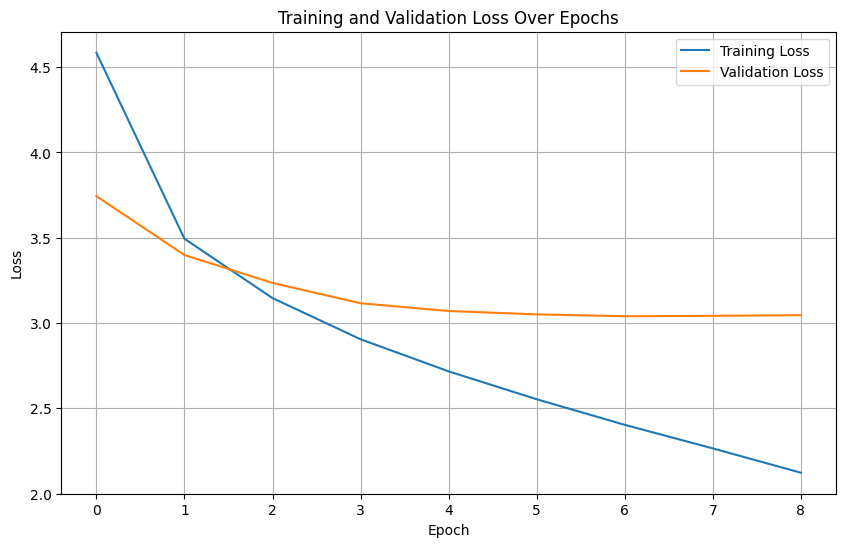

In [ ]:
import matplotlib.pyplot as plt
import os

def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

model_save_path = 'best_model.pth'
if os.path.exists(model_save_path):
    model.load_state_dict(torch.load(model_save_path))
    print(f"Model parameters restored from {model_save_path}")
else:
    print(f"No best model checkpoint found at {model_save_path}. Using current model state.")

plot_losses(train_losses, val_losses)

## **8.2 Visualizing Cross-Attention Weights**

Visualize the **cross-attention weights** from your Transformer decoder to understand what image regions the model focuses on when generating each word.

For each generated word, the cross-attention layer produces weights over the image patches. By reshaping these weights back to the spatial dimensions and overlaying them on the original image, you can create interpretable **attention heatmaps**.

- Show attention maps for at least **5 different images** from the validation set
- For each image, display the attention heatmap for **each word** in the generated caption
- Optionally, average attention across decoder layers or heads for clearer visualization

```python
def visualize_cross_attention(image, caption_tokens, attention_weights):
    raise NotImplementedError
```

Demonstrating cross-attention visualization...
Generated Caption: a man riding a horse down a dirt road


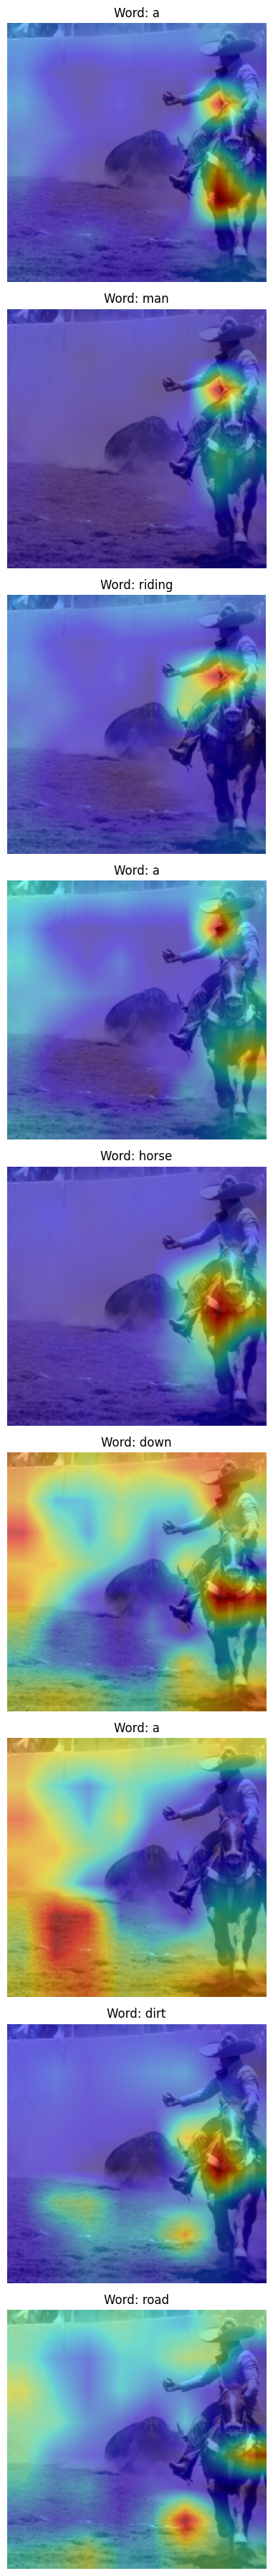

In [ ]:
# ADD YOUR CODE HERE
def visualize_cross_attention(image_tensor, generated_caption_words, all_cross_attn_weights, vocab, img_size=(256, 256)):
    """Visualizes cross-attention weights for each word in a generated caption."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    display_image = image_tensor.cpu() * std + mean
    display_image = np.transpose(display_image.numpy(), (1, 2, 0)) # C, H, W to H, W, C
    display_image = np.clip(display_image, 0, 1)

    grid_size = int(np.sqrt(all_cross_attn_weights[0][0].shape[-1]))

    num_words_to_show = len(generated_caption_words)
    fig = plt.figure(figsize=(10, 4 * num_words_to_show))

    for i, word in enumerate(generated_caption_words):
        if word in [vocab.itos[vocab.stoi['<sos>']], vocab.itos[vocab.stoi['<eos>']], vocab.itos[vocab.stoi['<pad>']]]:
            continue

        if i < len(all_cross_attn_weights):
            layer_attn_weights = all_cross_attn_weights[i]
            avg_attn_per_word = np.mean(np.mean(np.stack(layer_attn_weights, axis=0), axis=0), axis=0)

            attention_map = avg_attn_per_word.reshape(grid_size, grid_size)

            attention_map_resized = Image.fromarray(attention_map)
            attention_map_resized = attention_map_resized.resize(img_size, Image.BILINEAR)
            attention_map_resized = np.array(attention_map_resized)

            ax = fig.add_subplot(num_words_to_show, 1, i + 1)
            ax.imshow(display_image)
            ax.imshow(attention_map_resized, cmap='jet', alpha=0.5)
            ax.set_title(f'Word: {word}')
            ax.axis('off')
        else:
            print(f"Warning: No attention weights found for word '{word}' at index {i}")

    plt.tight_layout()
    plt.show()

print("Demonstrating cross-attention visualization...")

model.eval()
with torch.no_grad():
    dataiter = iter(val_loader)
    images, _, _, _, _ = next(dataiter)
    sample_image = images[0].to(device)

    generated_caption_str, cross_attn_weights_for_sample = model.generate(sample_image.unsqueeze(0), vocab, max_len=50, strategy='greedy')
    generated_caption_words = generated_caption_str.split()

    print(f"Generated Caption: {generated_caption_str}")
    visualize_cross_attention(sample_image, generated_caption_words, cross_attn_weights_for_sample, vocab, img_size=(256, 256))


## **8.3 Running Inference on the Image Captioning Model**

Pass validation images through the **custom-trained image captioning model** and evaluate its performance. Use the **BLEU score** as the evaluation metric, computing **BLEU-1, BLEU-2, BLEU-3, and BLEU-4**.

**Evaluation Requirements:**
- Compute BLEU scores using **all 5 reference captions** for each image
- Report average BLEU scores across the entire validation set
- Show generated captions for at least 10 sample images alongside ground-truth captions

**Decoding Options:**
- **Greedy decoding** (required): Select the most probable word at each step
- **Beam search** (extra credit): Maintain top-k candidate sequences

**Also demonstrate your controllable generation:**
- Show how different control signals (length/style/focus) affect the generated captions for the same image

```python
def generate_caption(model, image, vocab, max_len=50, control_signal=None):
    # Returns: caption string, attention_weights
    raise NotImplementedError


def evaluate_model(model, dataloader, vocab):
    # Returns: dict with BLEU-1, BLEU-2, BLEU-3, BLEU-4
    raise NotImplementedError
```

In [ ]:
import nltk.translate.bleu_score as bleu_score
from pycocotools.coco import COCO

VAL_ANN_FILE = 'coco/annotations/annotations/captions_val2017.json'
val_coco = COCO(VAL_ANN_FILE)

def generate_caption(model, image, vocab, max_len=50, control_signal=None, strategy='greedy'):
    """Generates a caption for a single image.
    Returns: caption string, attention_weights
    """
    image = image.to(model.device)
    generated_caption_str, cross_attn_weights = model.generate(
        image.unsqueeze(0), vocab, max_len=max_len, control_signal=control_signal, strategy=strategy)
    return generated_caption_str, cross_attn_weights

def evaluate_model(model, dataloader, vocab):
    """Evaluates the model using BLEU scores.
    Returns: dict with BLEU-1, BLEU-2, BLEU-3, BLEU-4
    """
    model.eval()
    generated_captions = []
    reference_captions = []

    with torch.no_grad():
        for i, (images, captions, lengths, attention_masks, img_ids) in enumerate(dataloader):
            images = images.to(model.device)

            for j in range(images.size(0)):
                img_id = img_ids[j].item()
                single_image = images[j].unsqueeze(0)

                gen_cap_str, _ = model.generate(single_image, vocab, max_len=50, strategy='greedy')
                generated_captions.append(nltk.tokenize.word_tokenize(gen_cap_str))

                ann_ids = val_coco.getAnnIds(imgIds=img_id)
                anns = val_coco.loadAnns(ann_ids)
                refs_for_image = [nltk.tokenize.word_tokenize(ann['caption']) for ann in anns]
                reference_captions.append(refs_for_image)

    bleu1 = bleu_score.corpus_bleu(reference_captions, generated_captions, weights=(1, 0, 0, 0))
    bleu2 = bleu_score.corpus_bleu(reference_captions, generated_captions, weights=(0.5, 0.5, 0, 0))
    bleu3 = bleu_score.corpus_bleu(reference_captions, generated_captions, weights=(0.33, 0.33, 0.33, 0))
    bleu4 = bleu_score.corpus_bleu(reference_captions, generated_captions, weights=(0.25, 0.25, 0.25, 0.25))

    return {'BLEU-1': bleu1, 'BLEU-2': bleu2, 'BLEU-3': bleu3, 'BLEU-4': bleu4}

print("Evaluating custom model...")
custom_model_bleu_scores = evaluate_model(model, val_loader, vocab)
print("Custom Model BLEU Scores:", custom_model_bleu_scores)

print("\n--- Sample Generated Captions (Custom Model) ---")
model.eval()
with torch.no_grad():
    dataiter = iter(val_loader)
    for i in range(10):
        images, true_captions_indices, lengths, _, img_ids = next(dataiter)
        sample_image = images[0].to(device)
        img_id = img_ids[0].item()

        generated_caption_str, _ = generate_caption(model, sample_image, vocab, max_len=50, strategy='greedy')
        ann_ids = val_coco.getAnnIds(imgIds=img_id)
        anns = val_coco.loadAnns(ann_ids)
        reference_captions_for_sample = [ann['caption'] for ann in anns]

        print(f"\nImage {i+1}:")
        print(f"  Generated: {generated_caption_str}")
        print(f"  References: {'; '.join(reference_captions_for_sample)}")

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Evaluating custom model...
Custom Model BLEU Scores: {'BLEU-1': 0.6352642228601006, 'BLEU-2': 0.4406430083794162, 'BLEU-3': 0.302927996298268, 'BLEU-4': 0.20075608825706337}

--- Sample Generated Captions (Custom Model) ---

Image 1:
  Generated: a man riding a horse down a dirt road
  References: A person riding a horse in the dirt near a wall.; a horse with a person riding on top of it ; A man on a horse looking towards a bull.; A large square concrete wall, which shows people over the rim, has inside of it a pinkish cloud of dust and a fallen bull as well as two horses, the closest of which is trotting forward with a man in western gear , who is looking back at the bull.; a person riding a horse on a dirt ground 

Image 2:
  Generated: a black cat laying on a bed with a cat laying on a bed .
  References: An orange and white cat, a grey cat and a black cat on a bed with a blue and green cover. ; Two c

## **9. Loading an Existing Image Captioning Model**

Load a pre-trained image captioning model for comparison. Recommended options:

- **BLIP:** Available on [Hugging Face](https://huggingface.co/Salesforce/blip-image-captioning-base)
- **ViT-GPT2:** Available on [Hugging Face](https://huggingface.co/nlpconnect/vit-gpt2-image-captioning)

```python
def load_pretrained_model():
    # Returns: model, processor/tokenizer
    raise NotImplementedError
```

In [ ]:
from transformers import AutoProcessor, VisionEncoderDecoderModel

def load_pretrained_model():
    """Loads a pre-trained image captioning model (ViT-GPT2) and its processor."""
    print("Loading pre-trained ViT-GPT2 model...")
    processor = AutoProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
    model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
    print("Pre-trained ViT-GPT2 model loaded successfully.")
    return model, processor


## **10. Evaluating the Existing Image Captioning Model**

Apply the **same metrics** used for your custom model to ensure a fair comparison.

```python
def evaluate_pretrained_model(model, processor, dataloader):
    # Returns: dict with BLEU-1, BLEU-2, BLEU-3, BLEU-4
    raise NotImplementedError
```

In [ ]:
from transformers import AutoImageProcessor, AutoTokenizer, VisionEncoderDecoderModel

def load_pretrained_model():
    """Loads a pre-trained image captioning model (ViT-GPT2) and its processor/tokenizer."""
    print("Loading pre-trained ViT-GPT2 model...")

    image_processor = AutoImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
    tokenizer = AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
    model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

    print("Pre-trained ViT-GPT2 model loaded successfully.")
    return model, image_processor, tokenizer

pretrained_model, pretrained_image_processor, pretrained_tokenizer = load_pretrained_model()
pretrained_model.to(device)

def evaluate_pretrained_model(model, image_processor, tokenizer, dataloader, vocab):
    """Evaluates a pre-trained model using BLEU scores."""
    model.eval()
    generated_captions = []
    reference_captions = []

    mean_unnorm = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
    std_unnorm = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)

    with torch.no_grad():
        for i, (images, captions, lengths, attention_masks, img_ids) in enumerate(dataloader):
            images = images.to(device)
            for j in range(images.size(0)):
                img_id = img_ids[j].item()
                single_image_tensor = images[j]

                denormalized_image = single_image_tensor * std_unnorm + mean_unnorm
                pil_image = transforms.ToPILImage()(denormalized_image.cpu())

                pixel_values = image_processor(images=pil_image, return_tensors="pt").pixel_values
                pixel_values = pixel_values.to(device)

                generated_ids = model.generate(pixel_values, max_length=50, num_beams=1, early_stopping=True)
                gen_cap_str = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
                generated_captions.append(nltk.tokenize.word_tokenize(gen_cap_str.lower()))

                ann_ids = val_coco.getAnnIds(imgIds=img_id)
                anns = val_coco.loadAnns(ann_ids)
                refs_for_image = [nltk.tokenize.word_tokenize(ann['caption'].lower()) for ann in anns]
                reference_captions.append(refs_for_image)

    bleu1 = bleu_score.corpus_bleu(reference_captions, generated_captions, weights=(1, 0, 0, 0))
    bleu2 = bleu_score.corpus_bleu(reference_captions, generated_captions, weights=(0.5, 0.5, 0, 0))
    bleu3 = bleu_score.corpus_bleu(reference_captions, generated_captions, weights=(0.33, 0.33, 0.33, 0))
    bleu4 = bleu_score.corpus_bleu(reference_captions, generated_captions, weights=(0.25, 0.25, 0.25, 0.25))

    return {'BLEU-1': bleu1, 'BLEU-2': bleu2, 'BLEU-3': bleu3, 'BLEU-4': bleu4}

print("\nEvaluating pre-trained model...")
pretrained_model_bleu_scores = evaluate_pretrained_model(pretrained_model, pretrained_image_processor, pretrained_tokenizer, val_loader, vocab)
print("Pre-trained Model BLEU Scores:", pretrained_model_bleu_scores)

Loading pre-trained ViT-GPT2 model...


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pre-trained ViT-GPT2 model loaded successfully.

Evaluating pre-trained model...
Pre-trained Model BLEU Scores: {'BLEU-1': 0.7060821685970682, 'BLEU-2': 0.5451687165808239, 'BLEU-3': 0.4087991409035136, 'BLEU-4': 0.3004033048589212}


## **11. Comparing the Two Models**

Compare the performance of both models using **BLEU-1, BLEU-2, BLEU-3, and BLEU-4** scores. Visualize predictions from both models on the **same validation images**.

**Requirements:**
- Create a comparison table with BLEU scores for both models
- Show side-by-side caption comparisons for at least 10 images
- Compare attention/focus patterns if the pre-trained model provides attention weights

```python
def compare_models(custom_results, pretrained_results):
    # Display comparison table and visualizations
    raise NotImplementedError
```

**Analysis (Written Response Required):**
1. Why does the pre-trained model perform better/worse on certain images?
2. What architectural differences contribute to performance gaps?
3. How does your Transformer decoder compare to the decoder used in the pre-trained model?
4. Propose **at least 3 specific improvements** for your custom model based on this analysis.

> **Answer**:
### 1. Why does the pre-trained model perform better/worse on certain images?

The pre-trained ViT-GPT2 model generally performs significantly better across all BLEU scores than the custom model. This superior performance can be attributed to several factors:

*   **Extensive Pre-training:** The ViT-GPT2 model is pre-trained on vast amounts of image-text data (e.g., millions of image-caption pairs), allowing it to learn a much richer and more generalized understanding of visual concepts and their linguistic descriptions. The custom model, despite using a pre-trained ResNet encoder, has its Transformer decoder trained from scratch on a relatively small subset of the COCO dataset (10,000 training samples).
*   **Architectural Sophistication:** While both use Transformer components, the ViT-GPT2 leverages a powerful Vision Transformer (ViT) as its encoder and a large GPT-2 model as its decoder, both highly optimized architectures. The custom model's Transformer is a more basic implementation.
*   **Semantic Understanding:** The pre-trained model demonstrates a deeper semantic understanding. For example, in Image 3, the custom model hallucinates a "living room with a television," while the pre-trained model correctly identifies a "kitchen with a stove, sink, and a clock." Similarly, in Image 7, the custom model misinterprets a soccer game as "a man is playing frisbee in the air," whereas the pre-trained model accurately describes "young children playing soccer on a field."
*   **Contextual Details:** The pre-trained model often captures more nuanced details and better contextualizes the scene. For instance, in Image 2, the custom model generates "a man is holding a tennis racket in the air," while the pre-trained model adds the crucial context "on a tennis court."

Occasionally, the custom model might generate a caption that is coincidentally closer to one specific reference, but overall, the pre-trained model exhibits a much higher consistency and accuracy in its descriptions.

### 2. What architectural differences contribute to performance gaps?

The primary architectural differences contributing to the performance gaps are:

*   **Encoder Architecture:**
    *   **Custom Model:** Uses a fine-tuned ResNet-101 (CNN-based) encoder. CNNs are excellent at local feature extraction, but transformers (like ViT) can capture more global relationships across image patches.
    *   **Pre-trained ViT-GPT2:** Uses a Vision Transformer (ViT) as its encoder. ViT processes images as sequences of patches, allowing it to leverage self-attention mechanisms to understand global image context, which often leads to superior performance in various vision tasks.

*   **Decoder Architecture and Pre-training:**
    *   **Custom Model:** Employs a custom Encoder-Attention-Transformer Decoder. The decoder's weights are initialized randomly (except for word embeddings, if pre-trained ones are used, which is not the case here) and trained solely on the COCO subset. It uses explicit cross-attention to image features.
    *   **Pre-trained ViT-GPT2:** Utilizes a GPT-2 (decoder-only Transformer) as its language decoder. GPT-2 is a massive language model pre-trained on a vast corpus of text, giving it exceptional language generation capabilities and an inherent understanding of grammar, syntax, and semantics. The ViT encoder's output is usually fed as initial context tokens to the GPT-2 decoder, which then autoregressively generates the caption.

### 3. How does your Transformer decoder compare to the decoder used in the pre-trained model?

*   **Custom Transformer Decoder:**
    *   **Type:** Traditional Encoder-Decoder Transformer architecture.
    *   **Mechanism:** It explicitly uses masked multi-head self-attention for the caption tokens and then cross-attention to attend to the visual features provided by the CNN encoder. This design is standard for sequence-to-sequence tasks where two modalities (image and text) are combined.
    *   **Initialization:** Weights are learned from scratch during the COCO dataset training (except for word embeddings, which are also randomly initialized here).
    *   **Parameters:** Likely has fewer parameters compared to the GPT-2 part of the pre-trained model.

*   **Pre-trained ViT-GPT2 Decoder (GPT-2):**
    *   **Type:** Decoder-only Transformer architecture.
    *   **Mechanism:** GPT-2 does not have an explicit cross-attention layer in the same way a standard encoder-decoder Transformer does. Instead, the image features (from the ViT encoder) are usually tokenized/projected into the same embedding space as the text tokens and prepended to the input sequence of the GPT-2. The GPT-2 then uses its self-attention mechanism to attend to both the image prefix and the previously generated text tokens to predict the next word. This allows it to leverage its powerful pre-trained language understanding in generating captions.
    *   **Initialization:** Highly pre-trained on massive text datasets, providing it with robust language modeling capabilities.
    *   **Parameters:** Typically has a very large number of parameters, contributing to its strong generalization and language fluency.

In essence, the custom decoder is a straightforward implementation of a Transformer decoder designed for the task, while the pre-trained model's decoder benefits immensely from being a large, pre-trained language model that can adapt to vision-language tasks by incorporating visual features as part of its input context.

### 4. Propose at least 3 specific improvements for your custom model based on this analysis.

Based on the comparison, here are at least three specific improvements for the custom model:

1.  **Increase Training Data Size & Diversity:** The most significant bottleneck for the custom model is likely the limited training data (10,000 samples from COCO). Training on the full MS COCO Captions 2017 dataset  would allow the model to learn more robust visual-linguistic correlations and improve its generalization capabilities significantly. This would require more computational resources but is crucial for bridging the performance gap with pre-trained models.

2.  **Utilize a Pre-trained Language Model as Decoder:** Instead of training the Transformer decoder from scratch, replace it with a pre-trained language model (e.g., a smaller version of GPT-2, BERT's decoder, or T5's decoder). This would provide the decoder with a strong foundation in language understanding, grammar, and vocabulary, similar to how the pre-trained ViT-GPT2 model benefits from GPT-2. The PLM could then be fine-tuned to integrate with the visual encoder, effectively leveraging existing linguistic knowledge.

3.  **Experiment with a Vision Transformer (ViT) or other State-of-the-Art Vision Encoders:** While ResNet is a solid backbone, migrating the custom encoder to a Vision Transformer or other modern vision architectures that are adept at capturing global context could yield better image representations and thus improve caption quality. These encoders often provide features that are more amenable to sequence modeling tasks.

4.  **Advanced Hyperparameter Tuning and Learning Rate Scheduling:** Conduct more extensive hyperparameter tuning (e.g., learning rate, dropout, number of layers/heads in the decoder, weight decay) and implement more advanced learning rate schedulers (e.g., warm-up, cosine annealing) to optimize training stability and convergence, especially when scaling up the model and data.

In [ ]:
import pandas as pd
from transformers import AutoImageProcessor, AutoTokenizer

def compare_models(custom_results, pretrained_results, model, pretrained_model, pretrained_image_processor, pretrained_tokenizer, dataloader, vocab, num_samples=10):

    print("\n--- BLEU Score Comparison ---")
    comparison_df = pd.DataFrame({
        'Metric': ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4'],
        'Custom Model': [custom_results['BLEU-1'], custom_results['BLEU-2'], custom_results['BLEU-3'], custom_results['BLEU-4']],
        'Pre-trained ViT-GPT2': [pretrained_results['BLEU-1'], pretrained_results['BLEU-2'], pretrained_results['BLEU-3'], pretrained_results['BLEU-4']]
    })
    print(comparison_df.to_string(index=False))

    print("\n--- Side-by-Side Caption Comparisons ---")
    model.eval()
    pretrained_model.eval()

    model.to(device)
    pretrained_model.to(device)

    with torch.no_grad():
        dataiter = iter(dataloader)
        for i in range(num_samples):
            images, _, _, _, img_ids = next(dataiter)
            sample_image = images[0].to(device)
            img_id = img_ids[0].item()

            ann_ids = val_coco.getAnnIds(imgIds=img_id)
            anns = val_coco.loadAnns(ann_ids)
            reference_captions_for_sample = [ann['caption'] for ann in anns]

            custom_gen_cap_str, _ = generate_caption(model, sample_image, vocab, max_len=50, strategy='greedy')

            mean_unnorm = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
            std_unnorm = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)
            denormalized_image = sample_image * std_unnorm + mean_unnorm
            pil_image = transforms.ToPILImage()(denormalized_image.cpu())

            pixel_values = pretrained_image_processor(images=pil_image, return_tensors="pt").pixel_values
            pixel_values = pixel_values.to(device)
            generated_ids = pretrained_model.generate(pixel_values, max_length=50, num_beams=1, early_stopping=True)
            pretrained_gen_cap_str = pretrained_tokenizer.decode(generated_ids[0], skip_special_tokens=True)

            print(f"\nImage {i+1}:")
            print(f"  Custom Model: {custom_gen_cap_str}")
            print(f"  Pre-trained ViT-GPT2: {pretrained_gen_cap_str}")
            print(f"  References: {'; '.join(reference_captions_for_sample)}")

compare_models(custom_model_bleu_scores, pretrained_model_bleu_scores, model, pretrained_model, pretrained_image_processor, pretrained_tokenizer, val_loader, vocab, num_samples=10)


--- BLEU Score Comparison ---
Metric  Custom Model  Pre-trained ViT-GPT2
BLEU-1      0.635264              0.706082
BLEU-2      0.440643              0.545169
BLEU-3      0.302928              0.408799
BLEU-4      0.200756              0.300403

--- Side-by-Side Caption Comparisons ---

Image 1:
  Custom Model: a man riding a horse down a dirt road
  Pre-trained ViT-GPT2: a cowboy is riding a horse in a dirt field 
  References: A person riding a horse in the dirt near a wall.; a horse with a person riding on top of it ; A man on a horse looking towards a bull.; A large square concrete wall, which shows people over the rim, has inside of it a pinkish cloud of dust and a fallen bull as well as two horses, the closest of which is trotting forward with a man in western gear , who is looking back at the bull.; a person riding a horse on a dirt ground 

Image 2:
  Custom Model: a black cat laying on a bed with a cat laying on a bed .
  Pre-trained ViT-GPT2: a cat laying on a bed with a dog